<a href="https://colab.research.google.com/github/mohishamongia/Coin-Classification/blob/main/coinclassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
!pip install kagglehub -q

In [13]:
import kagglehub

path = kagglehub.dataset_download("wanderdust/coin-images")
print("Path to dataset files:", path)

100%|██████████| 459M/459M [00:18<00:00, 25.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/wanderdust/coin-images/versions/1


In [14]:
import os

print("\nTop-level contents:")
for item in os.listdir(path):
    print(" ", item)

# Walk up to 3 levels to find train/validation/test
def _find_data_dir(base):
    for root, dirs, _ in os.walk(base):
        depth = root.replace(base, "").count(os.sep)
        if depth > 3:
            continue
        if "train" in dirs and "validation" in dirs and "test" in dirs:
            return root
    raise FileNotFoundError(
        f"Could not find train/validation/test folders under '{base}'. "
        "Check the printed directory structure above."
    )

def _find_json(base):
    for root, _, files in os.walk(base):
        if "cat_to_name.json" in files:
            return os.path.join(root, "cat_to_name.json")
    raise FileNotFoundError(f"cat_to_name.json not found under '{base}'.")

data_dir        = _find_data_dir(path)
data_train_path = os.path.join(data_dir, "train")
data_valid_path = os.path.join(data_dir, "validation")
data_test_path  = os.path.join(data_dir, "test")
json_path       = _find_json(path)

print("\nResolved paths:")
print("  data_dir :", data_dir)
print("  train    :", data_train_path)
print("  valid    :", data_valid_path)
print("  test     :", data_test_path)
print("  json     :", json_path)


Top-level contents:
  coins
  cat_to_name.json

Resolved paths:
  data_dir : /root/.cache/kagglehub/datasets/wanderdust/coin-images/versions/1/coins/data
  train    : /root/.cache/kagglehub/datasets/wanderdust/coin-images/versions/1/coins/data/train
  valid    : /root/.cache/kagglehub/datasets/wanderdust/coin-images/versions/1/coins/data/validation
  test     : /root/.cache/kagglehub/datasets/wanderdust/coin-images/versions/1/coins/data/test
  json     : /root/.cache/kagglehub/datasets/wanderdust/coin-images/versions/1/cat_to_name.json


In [15]:
import numpy as np
import json
from PIL import Image
import tensorflow as tf
import matplotlib.pyplot as plt


In [16]:
try:
    from tf_keras.preprocessing.image import ImageDataGenerator, img_to_array
    from tf_keras.preprocessing import image
    from tf_keras.applications.inception_v3 import InceptionV3
    from tf_keras.layers import Dense, Input, Dropout
    from tf_keras.models import Model
    from tf_keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
except ModuleNotFoundError:
    # Fallback for older TF / standard Keras 2 environments
    from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array
    from tensorflow.keras.preprocessing import image
    from tensorflow.keras.applications.inception_v3 import InceptionV3
    from tensorflow.keras.layers import Dense, Input, Dropout
    from tensorflow.keras.models import Model
    from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

In [17]:
with open(json_path, 'r') as f:
    cat_2_name = json.load(f)

print(cat_2_name['200'])

batch_size = 60

1 Kurus,Turkish Lira,turkey


# **Visualize dataset**

In [18]:
datagen_train = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    samplewise_std_normalization=True,
)

datagen_valid = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    samplewise_std_normalization=True,
)

datagen_test = ImageDataGenerator(
    rescale=1./255,
    samplewise_std_normalization=True,
)

train_generator = datagen_train.flow_from_directory(
    data_train_path,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',
)

valid_generator = datagen_valid.flow_from_directory(
    data_valid_path,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',
)

test_generator = datagen_test.flow_from_directory(
    data_test_path,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',
)

Found 6413 images belonging to 211 classes.
Found 844 images belonging to 211 classes.


/usr/local/lib/python3.12/dist-packages/tf_keras/src/preprocessing/image.py:1469: UserWarning: This ImageDataGenerator specifies `samplewise_std_normalization`, which overrides setting of `samplewise_center`.
  warnings.warn(


Found 844 images belonging to 211 classes.


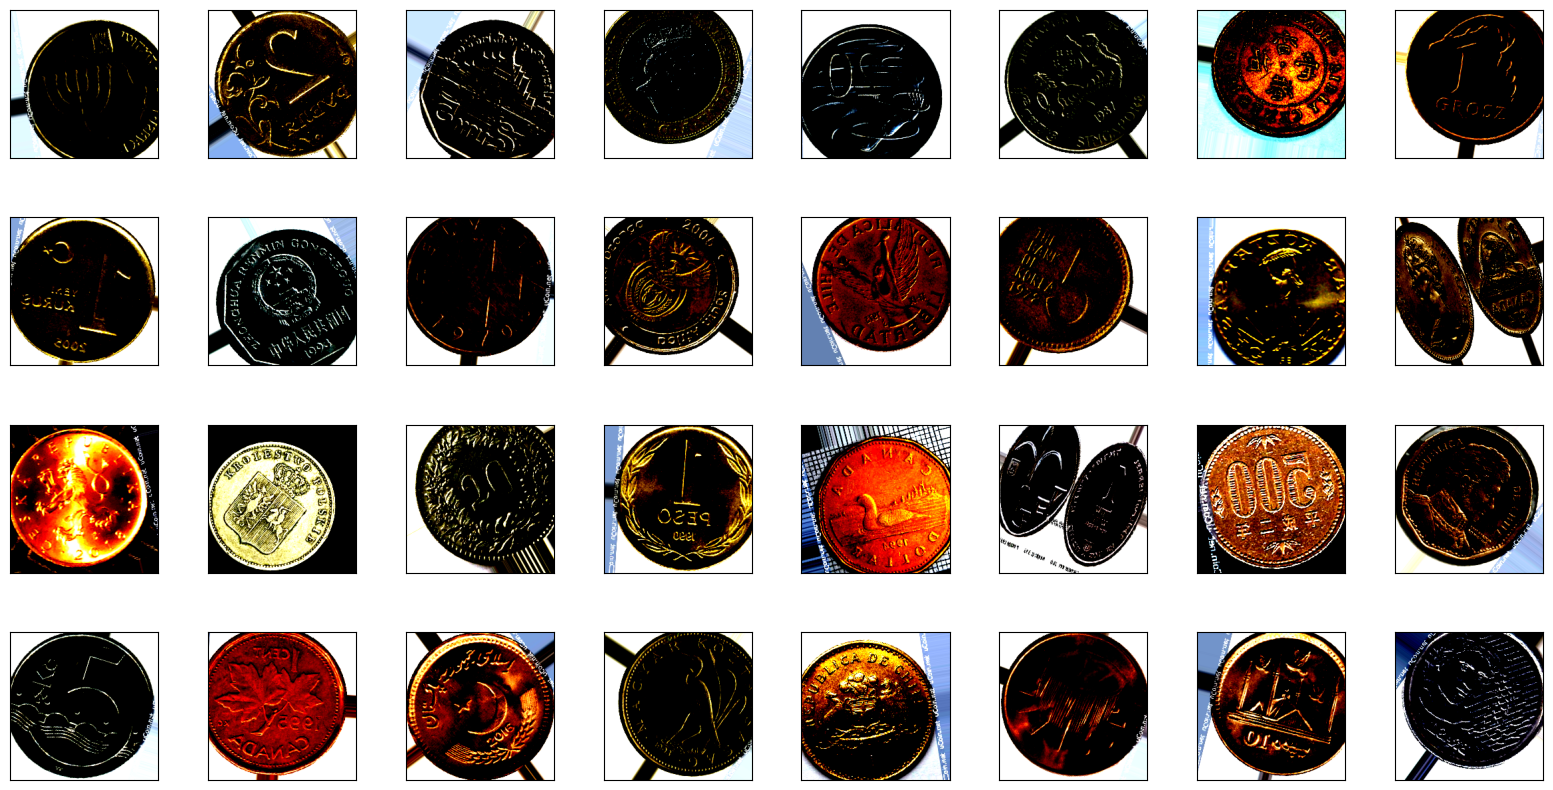

In [19]:
images, labels = train_generator.next()

fig = plt.figure(figsize=(20, 10))
fig.subplots_adjust(wspace=0.2, hspace=0.4)
for i, img in enumerate(images[:32]):
    ax = fig.add_subplot(4, 8, i + 1, xticks=[], yticks=[])
    ax.imshow(img)
    image_idx = np.argmax(labels[i])
plt.show()

# **Define Inception model**

In [20]:
int_to_dir = {v: k for k, v in train_generator.class_indices.items()}


In [ ]:
input_tensor = Input(shape=(224, 224, 3))

base_model = InceptionV3(
    include_top=False,
    weights='imagenet',
    input_tensor=input_tensor,
    input_shape=(224, 224, 3),
    pooling='max',
)

for layer in base_model.layers:
    layer.trainable = True

x = Dense(512, activation='relu')(base_model.output)
x = Dropout(0.8)(x)
predictions = Dense(211, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)


# **Train the model**

In [ ]:
num_train = len(train_generator.filenames)
num_valid = len(valid_generator.filenames)
num_test  = len(test_generator.filenames)

checkpointer = ModelCheckpoint(
    filepath='model.weights.best.hdf5',
    verbose=1,
    save_best_only=True,
)

scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=5,
    min_lr=1e-8,
    verbose=1,
)

early_stopper = EarlyStopping(
    monitor='val_loss',
    patience=12,
    verbose=0,
    restore_best_weights=True,
)

# **Save the model**

In [ ]:
history = model.fit(
    train_generator,
    steps_per_epoch=num_train // batch_size,
    epochs=100,
    verbose=1,
    callbacks=[checkpointer, scheduler, early_stopper],
    validation_data=valid_generator,
    validation_steps=num_valid // batch_size,
)

model.save('inceptionv3.h5')

# **Evaluate the model**

In [ ]:
score = model.evaluate(test_generator, steps=num_test // batch_size, verbose=1)
print('\n', 'Test accuracy:', score[1])


In [ ]:
def get_prediction(img, real_label):
    img_array_display = np.array(img) / 255.0          # for display only

    img_array = img_array_display.copy()
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]
    img_array = (img_array - mean) / std               # normalised for inference

    img_expand = np.expand_dims(img_array, axis=0)
    prediction = model.predict(img_expand)
    pred_index = np.argmax(prediction)
    dir_int    = int_to_dir[pred_index]
    label_name = cat_2_name[str(dir_int)]

    plt.imshow(img_array_display)  # display original colours, not normalised
    plt.axis('off')
    plt.show()

    print("Predicted: {}\nReal:      {}".format(label_name, cat_2_name[str(real_label)]))
    print()

Predicted: 2 Rupees,Pakistan Rupee,pakistan
Real:      2 Rupees,Pakistan Rupee,pakistan

Predicted: 1 Krone,Norwegian Krone,norway
Real:      100 Won,Korean Won,south_korea

Predicted: 5 Forint,Hungarian Forint,hungary
Real:      1 Cent,US Dollar,usa

Predicted: 20 Sen,Malaysian Ringgit,malaysia
Real:      10 Sen,Malaysian Ringgit,malaysia

Predicted: 1 Peso,Chilean Peso,chile
Real:      20 euro Cent,Euro,spain

Predicted: 5 Francs,Swiss Franc,switzerland
Real:      1 2 Franc,Swiss Franc,switzerland

Predicted: 5 Pence,British Pound,united_kingdom
Real:      5 Rappen,Swiss Franc,switzerland

Predicted: 1 Kurus,Turkish Lira,turkey
Real:      1 Kurus,Turkish Lira,turkey

Predicted: 50 Korun,Czech Koruna,czech_republic
Real:      50 Korun,Czech Koruna,czech_republic

Predicted: 5 Rupees,Pakistan Rupee,pakistan
Real:      5 Rupees,Pakistan Rupee,pakistan



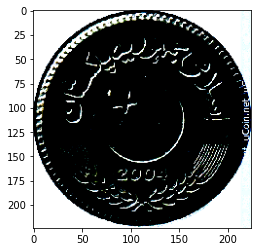

In [ ]:
for i in range(10):
    random_index = np.random.randint(0, len(test_generator.filenames))
    img_rel_path = test_generator.filenames[random_index]

    img = image.load_img(
        os.path.join(data_test_path, img_rel_path),
        target_size=(224, 224),
    )

    real_label = img_rel_path.split("/")[0]
    get_prediction(img, real_label)